# Pass@k vs step cross analysis

Focus: analyze how pass@k scales with k at different steps, and compare algorithm-specific pass@k profiles.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlepad"] = 12

# Robust data directory resolver (works from repo root or final_results/tools)

def get_data_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = []
    for parent in [cwd] + list(cwd.parents):
        candidates.append(parent / "final_results" / "data")
        candidates.append(parent / "data")
    for c in candidates:
        if c.exists():
            return c
    raise FileNotFoundError(f"Could not locate data directory in candidates: {candidates}")

DATA_DIR = get_data_dir()


DATA_DIR = get_data_dir()

combined = pd.read_csv(DATA_DIR / 'combined_wide.csv')
combined = combined.drop(columns=[c for c in ['Unnamed: 0'] if c in combined.columns])
combined['seed'] = combined['seed'].astype(str)
metrics = [c for c in combined.columns if c.startswith('pass@') or c == 'avg@32']
passk_metrics = [m for m in metrics if m.startswith('pass@')]


DATA_DIR_CANDIDATES = [
    Path.cwd() / "final_results" / "data",
    Path.cwd().parent / "final_results" / "data",
    Path.cwd() / "data",
    Path.cwd().parents[1] / "final_results" / "data",
    Path(__file__).resolve().parents[1] / "data" if '__file__' in globals() else Path.cwd() / "final_results" / "data",
]

# Robust data path resolver (works when running from repo root or final_results/tools)

# Robust data path resolver (works when running from repo root or final_results/tools)

def resolve_data_path(filename: str) -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "final_results" / "data" / filename,
        cwd / "data" / filename,
    ]
    for parent in [cwd] + list(cwd.parents):
        candidates.append(parent / "final_results" / "data" / filename)
        candidates.append(parent / "data" / filename)
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {filename} in candidates: {candidates}")




In [2]:

mean_df = combined.groupby(['Step', 'algorithm'], as_index=False)[passk_metrics].mean()
final_step = int(mean_df['Step'].max())
final_df = mean_df[mean_df['Step'] == final_step]

# Pick top algorithms by pass@1 for detailed heatmaps
algo_order = (
    final_df.sort_values('pass@1', ascending=False)['algorithm']
    .head(10)
    .tolist()
)


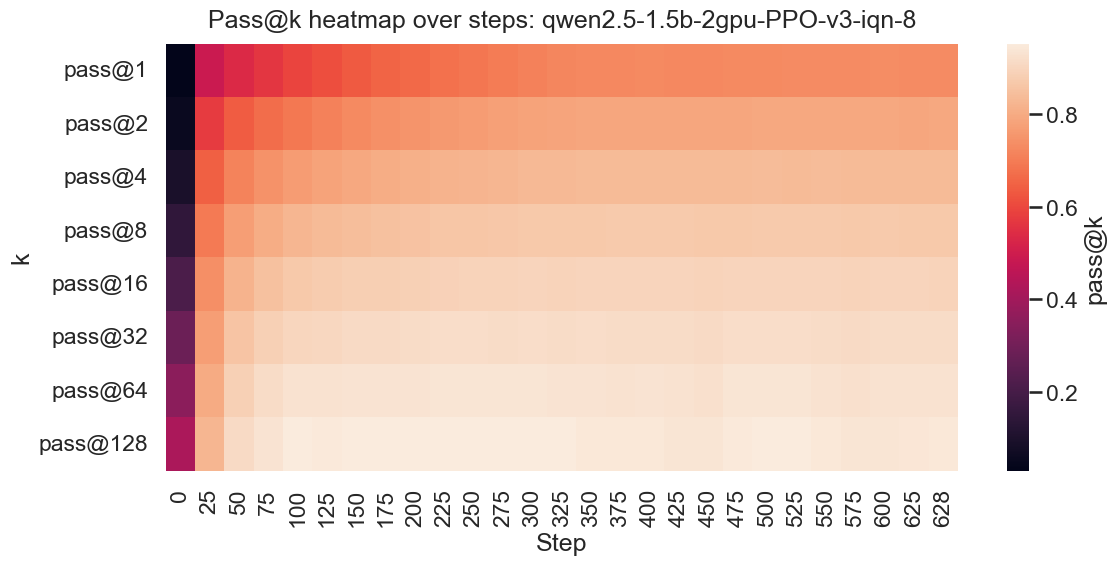

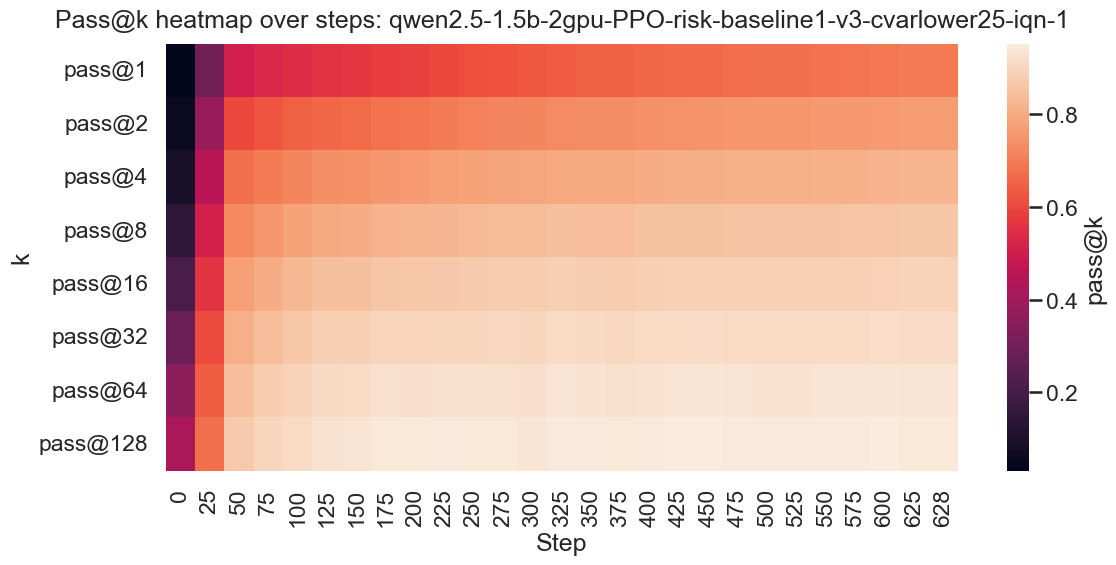

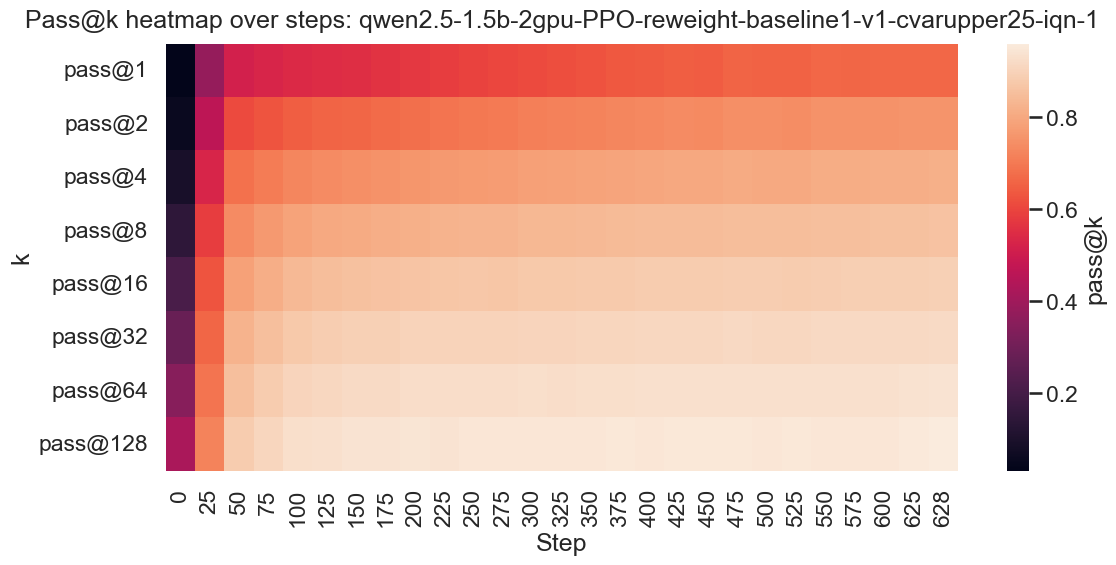

In [3]:

# Plot set A: heatmaps (Step x k) for top algorithms
k_order = sorted(passk_metrics, key=lambda x: int(x.split('@')[1]))
for algo in algo_order:
    sub = mean_df[mean_df['algorithm'] == algo]
    pivot = sub.set_index('Step')[k_order].T
    plt.figure(figsize=(12, 6))
    sns.heatmap(pivot, cmap='rocket', cbar_kws={'label': 'pass@k'})
    plt.title(f'Pass@k heatmap over steps: {algo}')
    plt.xlabel('Step')
    plt.ylabel('k')
    plt.tight_layout()
    plt.show()
    plt.close()


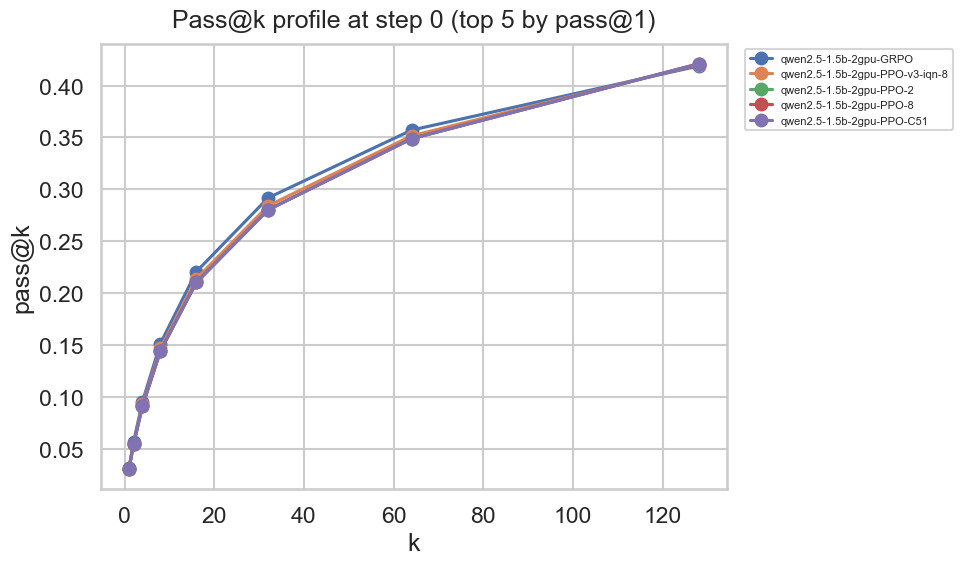

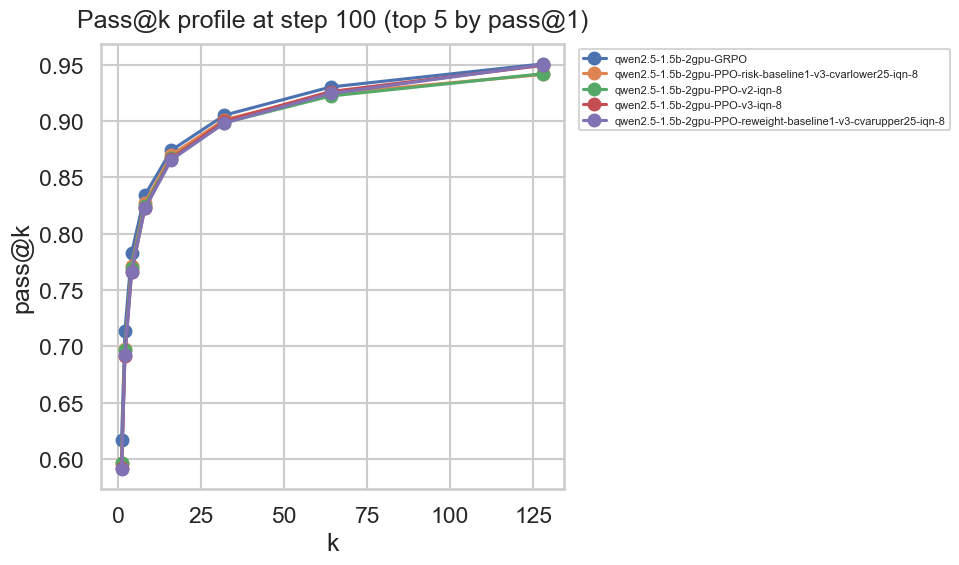

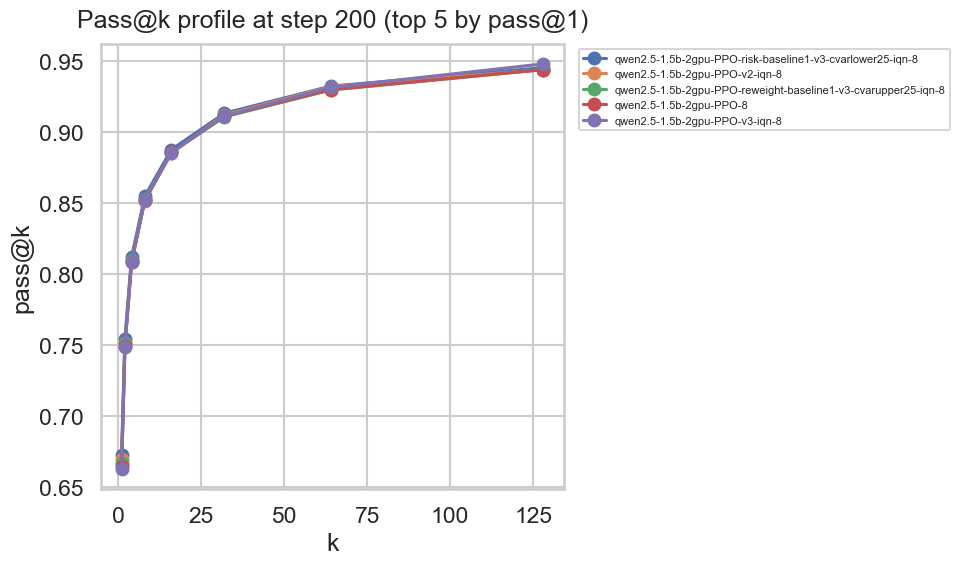

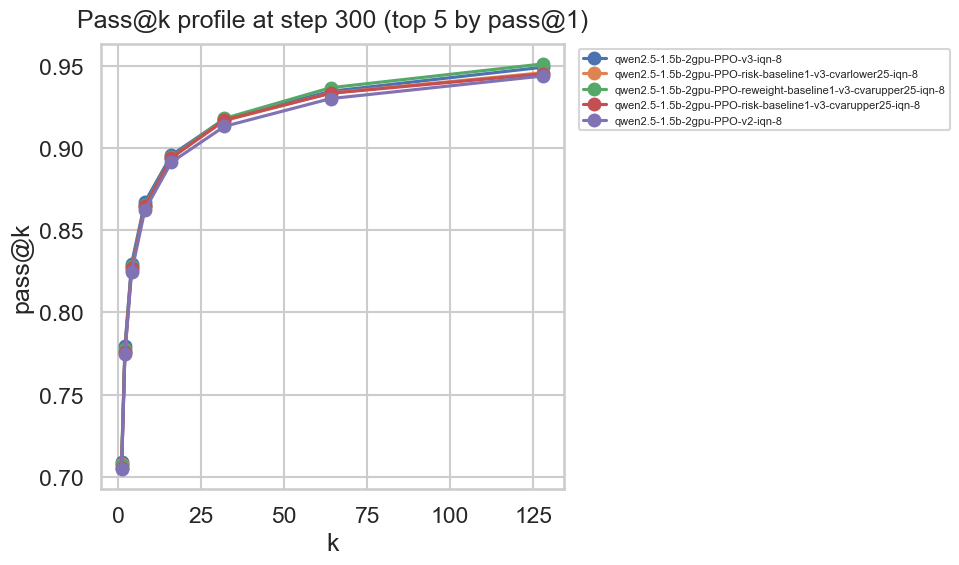

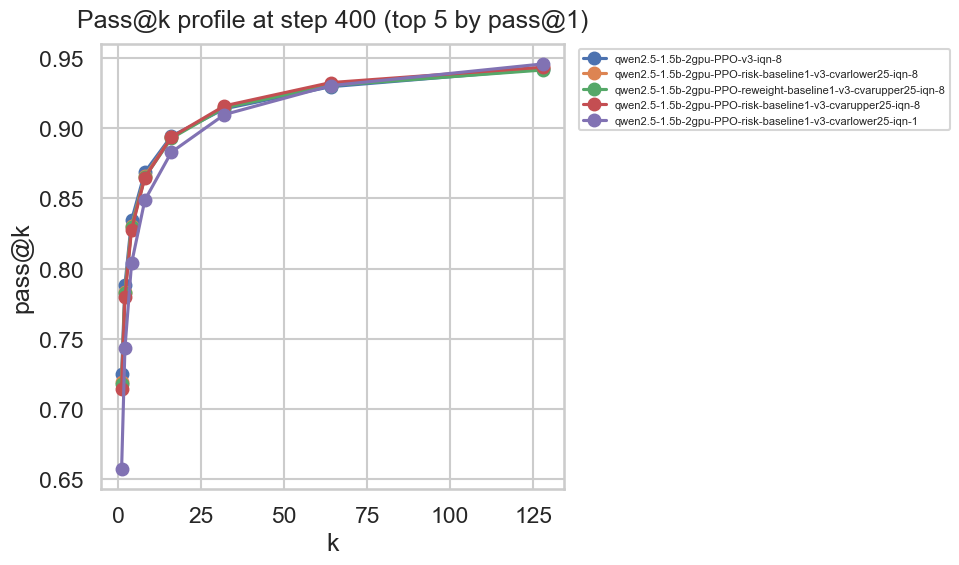

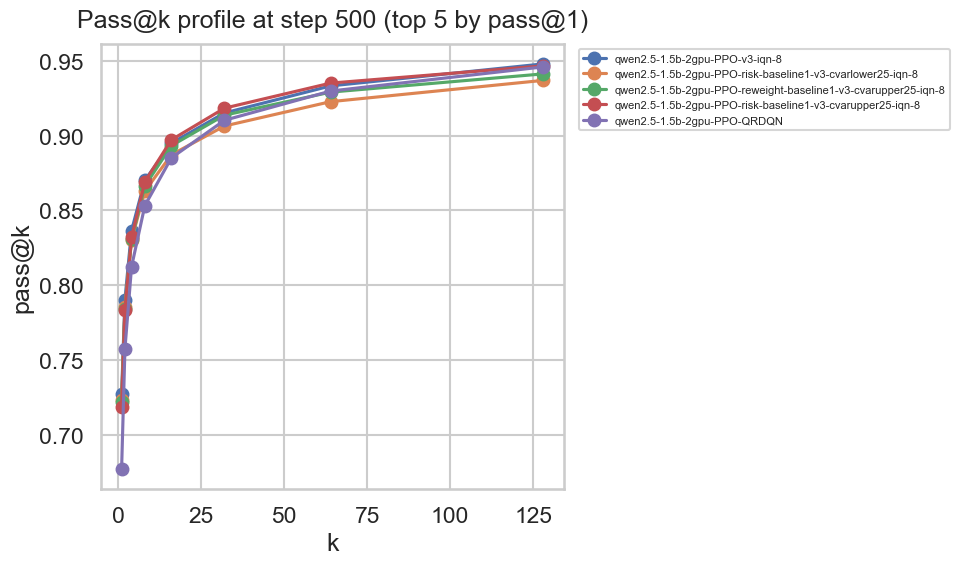

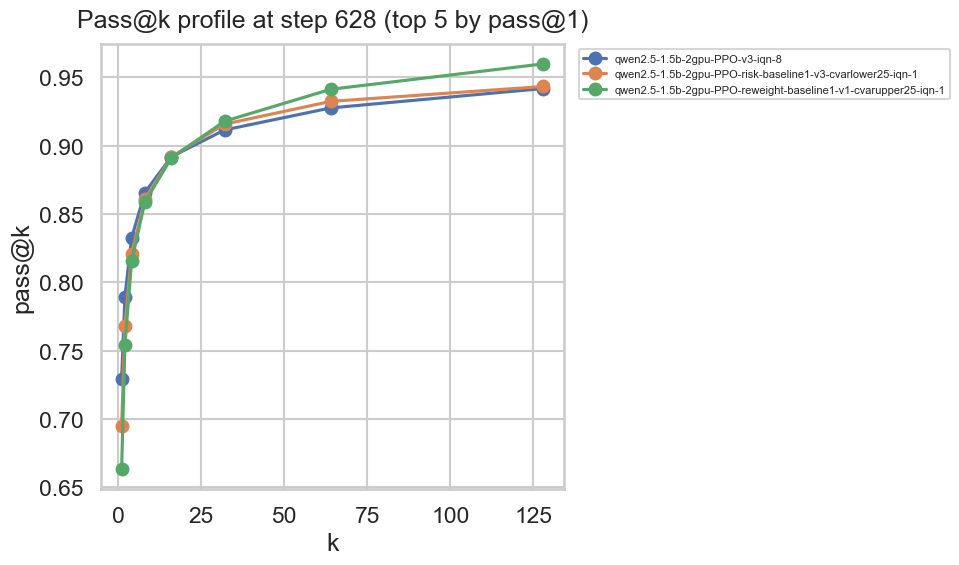

In [4]:

# Plot set B: pass@k profiles at selected steps
for step in [0, 100, 200, 300, 400, 500, 628]:
    sub = mean_df[mean_df['Step'] == step]
    top = sub.sort_values('pass@1', ascending=False)['algorithm'].head(5).tolist()
    plt.figure(figsize=(10, 6))
    for algo in top:
        row = sub[sub['algorithm'] == algo][k_order].iloc[0]
        plt.plot([int(k.split('@')[1]) for k in k_order], row.values, marker='o', label=algo)
    plt.title(f'Pass@k profile at step {step} (top 5 by pass@1)')
    plt.xlabel('k')
    plt.ylabel('pass@k')
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()
    plt.close()


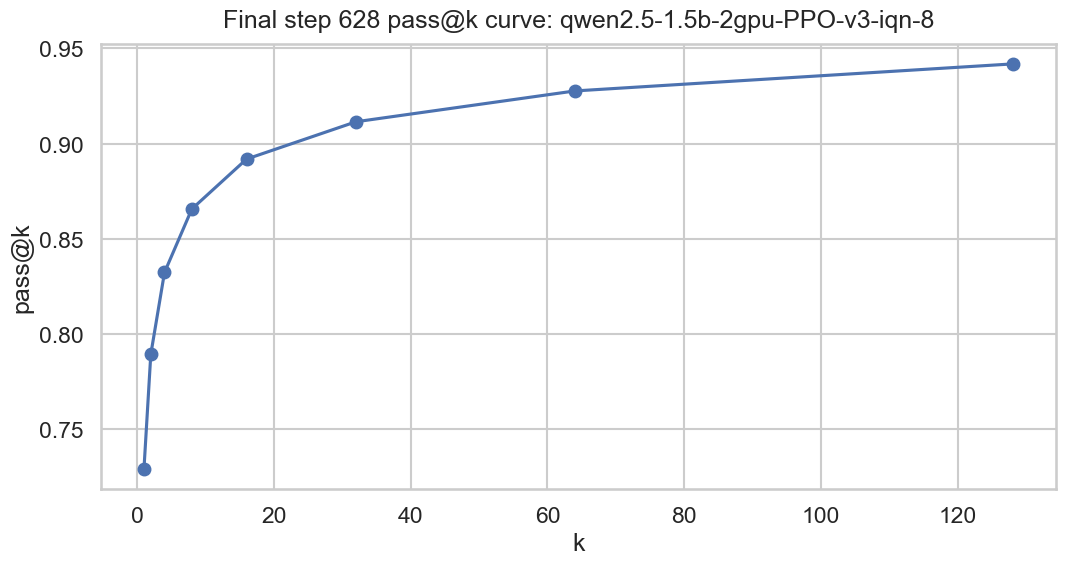

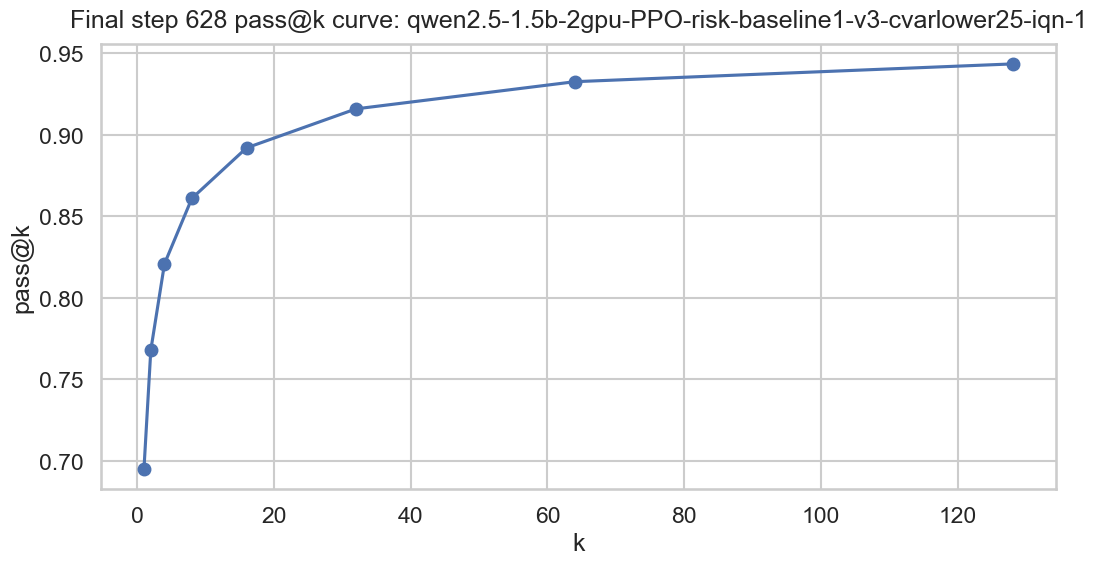

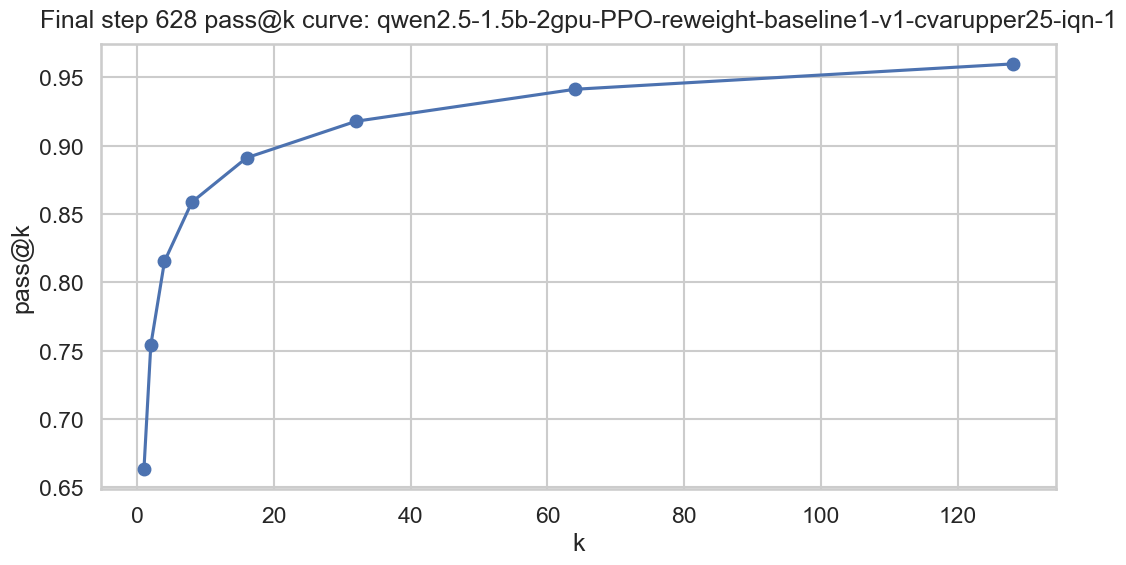

In [5]:

# Plot set C: per-algorithm pass@k at final step
for algo in algo_order:
    row = final_df[final_df['algorithm'] == algo][k_order].iloc[0]
    plt.figure()
    plt.plot([int(k.split('@')[1]) for k in k_order], row.values, marker='o')
    plt.title(f'Final step {final_step} pass@k curve: {algo}')
    plt.xlabel('k')
    plt.ylabel('pass@k')
    plt.tight_layout()
    plt.show()
    plt.close()
